# 10 — Substitute Product Recommender

**Purpose:** Model 4. Hybrid recommender using sentence-transformer embeddings (content)
and implicit ALS (collaborative filtering). Evaluate offline with Recall@K, MRR, NDCG@K.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow
import scipy.sparse as sp

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

from src.features import load_raw
from src.recommender import (
    build_description_embeddings,
    content_similarity,
    build_interaction_matrix,
    train_als,
    hybrid_recommend,
    recall_at_k,
    reciprocal_rank,
    ndcg_at_k,
    save_recommender_artifacts,
)

mlflow.set_tracking_uri('../mlflow/mlruns')
mlflow.set_experiment('retail-returns-intelligence')
print('Setup OK')

Setup OK


## 1. Load data and build product catalogue

In [2]:
df = load_raw('../data/raw/online_retail_II.xlsx')
purchases = df[df['is_return'] == 0].copy()

print(f'Total transactions: {len(df):,}  |  Purchases (non-return): {len(purchases):,}')
print(f'Unique products:    {df["stock_code"].nunique():,}')
print(f'Unique customers:   {df["customer_id"].dropna().nunique():,}')

Total transactions: 1,067,371  |  Purchases (non-return): 1,047,877
Unique products:    5,304
Unique customers:   5,942


## 2. Content-based: description embeddings (sentence-transformers)

In [3]:
# Build embeddings for all products with descriptions
# all-MiniLM-L6-v2: 384-dim, ~90MB, fast inference
print('Building description embeddings... (downloads model on first run)')
embeddings, stock_codes = build_description_embeddings(
    df,
    model_name='all-MiniLM-L6-v2',
    batch_size=128,
)
print(f'Embeddings shape: {embeddings.shape}  (L2-normalised)')
print(f'Products indexed: {len(stock_codes)}')

Building description embeddings... (downloads model on first run)


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/39 [00:00<?, ?it/s]

Embeddings shape: (4949, 384)  (L2-normalised)
Products indexed: 4949


## 3. Collaborative filtering: implicit ALS

In [4]:
matrix, cust_idx, prod_idx = build_interaction_matrix(df)
print(f'Interaction matrix: {matrix.shape[0]:,} users × {matrix.shape[1]:,} items, nnz={matrix.nnz:,}')

with mlflow.start_run(run_name='als-recommender'):
    mlflow.log_params({'factors': 64, 'iterations': 20, 'regularization': 0.01})
    als_model = train_als(matrix, factors=64, iterations=20, regularization=0.01)
    mlflow.log_metric('n_users', matrix.shape[0])
    mlflow.log_metric('n_items', matrix.shape[1])
print('ALS training complete')

Interaction matrix: 5,881 users × 4,631 items, nnz=481,947


  0%|          | 0/20 [00:00<?, ?it/s]

ALS training complete


## 4. Hybrid recommendation for a sample returned item

In [5]:
# Category return rates for filtering substitutes
cat_return = pd.read_parquet('../data/processed/category_return_rates.parquet')
cat_return_dict = dict(zip(cat_return['stock_code'], cat_return['category_return_rate']))

# Find a returned item that exists in both content and CF indices
returns = df[df['is_return'] == 1]
common_items = set(stock_codes.values) & set(prod_idx.values)
returned_in_both = returns[returns['stock_code'].isin(common_items)]['stock_code'].value_counts()

query_item = returned_in_both.index[0]  # most-returned item in both indices
query_desc = df[df['stock_code']==query_item]['description'].dropna().iloc[0]
print(f'Query item: {query_item} — {query_desc}')

# Content recommendations
content_stock_codes = stock_codes.reset_index(drop=True)  # align with embedding rows
query_emb_idx = content_stock_codes[content_stock_codes == query_item].index[0]
query_embedding = embeddings[query_emb_idx]
content_top_idx = content_similarity(query_embedding, embeddings, top_k=20)
content_top_codes = content_stock_codes.iloc[content_top_idx].tolist()

# CF recommendations
cf_item_idx = list(prod_idx).index(query_item)
cf_ids, cf_scores = als_model.similar_items(cf_item_idx, N=20)
cf_top_codes = [prod_idx[i] for i in cf_ids]

# Build rank arrays over a shared candidate pool for hybrid fusion
candidate_pool = list(dict.fromkeys(content_top_codes + cf_top_codes))  # preserve order, deduplicate
N = len(candidate_pool)

content_rank_arr = np.full(N, N + 1, dtype=float)
for rank, code in enumerate(content_top_codes):
    if code in candidate_pool:
        idx = candidate_pool.index(code)
        content_rank_arr[idx] = rank + 1

cf_rank_arr = np.full(N, N + 1, dtype=float)
for rank, code in enumerate(cf_top_codes):
    if code in candidate_pool:
        idx = candidate_pool.index(code)
        cf_rank_arr[idx] = rank + 1

hybrid_top_idx = hybrid_recommend(content_rank_arr, cf_rank_arr, alpha=0.5, top_k=5)
hybrid_top_codes = [candidate_pool[i] for i in hybrid_top_idx]

# Filter to lower-return-rate items (better substitutes)
query_rr = cat_return_dict.get(query_item, 0)
print(f'\nQuery item return rate: {query_rr:.1%}')
print('\nTop-5 hybrid recommendations:')
for rank, code in enumerate(hybrid_top_codes, 1):
    desc_rows = df[df['stock_code']==code]['description'].dropna()
    desc = desc_rows.iloc[0][:60] if len(desc_rows) > 0 else 'N/A'
    rr = cat_return_dict.get(code, float('nan'))
    flag = '✓ lower rr' if not np.isnan(rr) and rr < query_rr else ''
    print(f'  {rank}. {code}  {desc:<60}  return rate: {rr:.1%}  {flag}')

Query item: M — Manual

Query item return rate: 37.9%

Top-5 hybrid recommendations:
  1. M  Manual                                                        return rate: 37.9%  
  2. m  Manual                                                        return rate: 0.0%  ✓ lower rr
  3. 21445  12 PINK ROSE PEG PLACE SETTINGS                               return rate: 1.3%  ✓ lower rr


  4. 23595  adjustment                                                    return rate: 0.0%  ✓ lower rr
  5. 79413  GLASS WINE GLASS DECORATIONS                                  return rate: 0.0%  ✓ lower rr


## 5. Offline evaluation

In [6]:
# Hold-out: for each customer, hide last purchase → recommend → measure if we recover it
# Use only customers with 5+ purchases who appear in both content and CF indices
cust_purchase_counts = (
    purchases[purchases['stock_code'].isin(common_items) & purchases['customer_id'].notna()]
    .groupby('customer_id')['stock_code'].count()
)
eval_customers = cust_purchase_counts[cust_purchase_counts >= 5].index

rng = np.random.default_rng(42)
eval_sample = rng.choice(eval_customers, size=min(150, len(eval_customers)), replace=False)

K = 10
recalls, mrrs, ndcgs = [], [], []

for cust in eval_sample:
    cust_items = (
        purchases[(purchases['customer_id']==cust) & purchases['stock_code'].isin(common_items)]
        .sort_values('invoice_date')['stock_code'].tolist()
    )
    if len(cust_items) < 2:
        continue
    held_out  = cust_items[-1]
    past_item = cust_items[-2]

    try:
        # Content recs for past_item
        q_emb_idx = content_stock_codes[content_stock_codes == past_item].index
        if len(q_emb_idx) == 0:
            continue
        q_emb = embeddings[q_emb_idx[0]]
        ct_idx = content_similarity(q_emb, embeddings, top_k=K+5)
        ct_codes = content_stock_codes.iloc[ct_idx].tolist()

        # CF recs
        if past_item not in list(prod_idx):
            continue
        cf_idx_q = list(prod_idx).index(past_item)
        cf_ids_q, _ = als_model.similar_items(cf_idx_q, N=K+5)
        cf_codes_q = [prod_idx[i] for i in cf_ids_q]

        # Hybrid
        pool = list(dict.fromkeys(ct_codes + cf_codes_q))
        M = len(pool)
        ct_r = np.full(M, M+1, dtype=float)
        for r, c in enumerate(ct_codes):
            if c in pool:
                ct_r[pool.index(c)] = r + 1
        cf_r = np.full(M, M+1, dtype=float)
        for r, c in enumerate(cf_codes_q):
            if c in pool:
                cf_r[pool.index(c)] = r + 1
        top_idx_h = hybrid_recommend(ct_r, cf_r, alpha=0.5, top_k=K)
        recs_h = [pool[i] for i in top_idx_h]

        recalls.append(recall_at_k(recs_h, [held_out], K))
        mrrs.append(reciprocal_rank(recs_h, [held_out]))
        ndcgs.append(ndcg_at_k(recs_h, [held_out], K))
    except Exception:
        pass

mean_recall = np.mean(recalls) if recalls else 0
mean_mrr    = np.mean(mrrs)    if mrrs    else 0
mean_ndcg   = np.mean(ndcgs)   if ndcgs   else 0

print(f'Offline Evaluation (K={K}, n={len(recalls)} customers):')
print(f'  Recall@{K}:  {mean_recall:.4f}')
print(f'  MRR@{K}:     {mean_mrr:.4f}')
print(f'  NDCG@{K}:    {mean_ndcg:.4f}')

with mlflow.start_run(run_name='hybrid-rec-eval'):
    mlflow.log_metrics({f'recall_at_{K}': mean_recall,
                        f'mrr_at_{K}':    mean_mrr,
                        f'ndcg_at_{K}':   mean_ndcg})

Offline Evaluation (K=10, n=150 customers):
  Recall@10:  0.0933
  MRR@10:     0.0324
  NDCG@10:    0.0464


## 6. Return-rate reduction plot and save artefacts

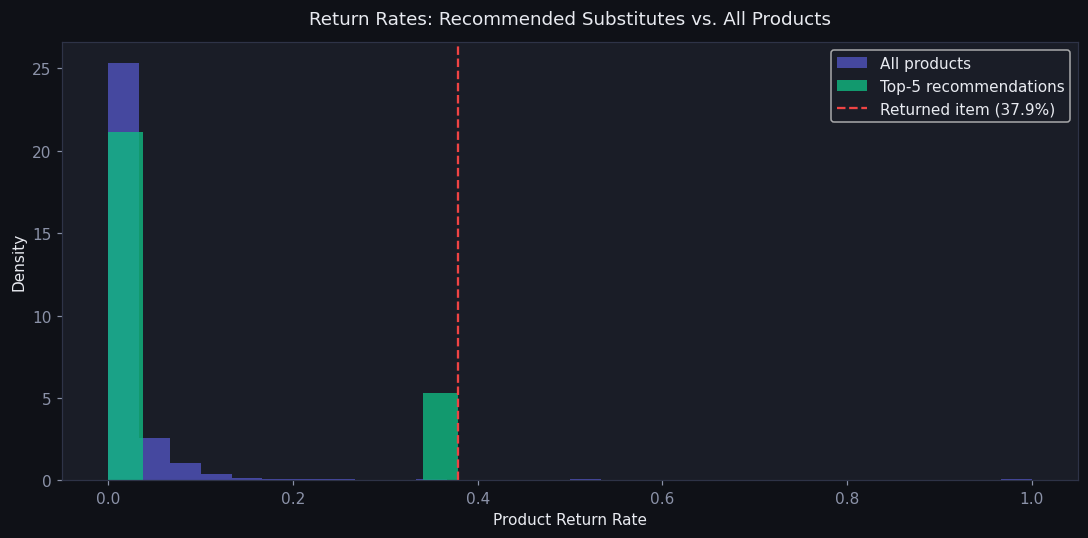

In [7]:
# Show distribution of return rates for top-recommended items vs. all items
all_rr = [v for v in cat_return_dict.values() if not np.isnan(v)]
rec_rr = [cat_return_dict.get(c, np.nan) for c in hybrid_top_codes if c in cat_return_dict]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_rr, bins=30, color='#6366f1', alpha=0.6, label='All products', density=True)
ax.hist(rec_rr, bins=10, color='#10b981', alpha=0.8, label='Top-5 recommendations', density=True)
ax.axvline(query_rr, color='#ef4444', linestyle='--', label=f'Returned item ({query_rr:.1%})')
ax.set_xlabel('Product Return Rate'); ax.set_ylabel('Density')
ax.set_title('Return Rates: Recommended Substitutes vs. All Products', pad=12)
ax.legend()
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/10_rec_return_rates.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [8]:
# Save all recommender artefacts
os.makedirs('../models', exist_ok=True)
save_recommender_artifacts(embeddings, stock_codes, als_model, cust_idx, prod_idx)

# Also persist the catalogue with return rates for API use
cat_df = (
    df.dropna(subset=['description', 'stock_code'])
    .groupby('stock_code')['description']
    .first()
    .reset_index()
    .merge(cat_return, on='stock_code', how='left')
)
cat_df.to_parquet('../data/processed/product_catalogue.parquet', index=False)

print('Saved recommender artefacts:')
print('  models/product_embeddings.npy')
print('  models/embedding_stock_codes.joblib')
print('  models/als_model.joblib')
print('  models/als_customer_index.joblib')
print('  models/als_product_index.joblib')
print('  data/processed/product_catalogue.parquet')
print(f'\nFinal metrics — Recall@{K}: {mean_recall:.4f}  MRR: {mean_mrr:.4f}  NDCG@{K}: {mean_ndcg:.4f}')

Saved recommender artefacts:
  models/product_embeddings.npy
  models/embedding_stock_codes.joblib
  models/als_model.joblib
  models/als_customer_index.joblib
  models/als_product_index.joblib
  data/processed/product_catalogue.parquet

Final metrics — Recall@10: 0.0933  MRR: 0.0324  NDCG@10: 0.0464
